In [70]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load Dataset

In [71]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("dataset_2191_sleep.csv")
df.head(10)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,3.3
1,1.000,6.6,4.5,42.0,3,1,3,8.3
2,3.385,44.5,14.0,60.0,1,1,1,12.5
3,0.920,5.7,NaN,25.0,5,2,3,16.5
4,2547.000,4603.0,69.0,624.0,3,5,4,3.9
5,10.550,179.5,27.0,180.0,4,4,4,9.8
6,0.023,0.3,19.0,35.0,1,1,1,19.7
7,160.000,169.0,30.4,392.0,4,5,4,6.2
8,3.300,25.6,28.0,63.0,1,2,1,14.5
9,52.160,440.0,50.0,230.0,1,1,1,9.7


## data Quality Assessment

In [72]:
df.dtypes

body_weight             float64
brain_weight            float64
max_life_span           float64
gestation_time          float64
predation_index           int64
sleep_exposure_index      int64
danger_index              int64
total_sleep             float64
dtype: object

We observe that some columns are stored as object type.
Incorrect data types can prevent proper calculations and time-based analysis.

### Convert Incorrect Data Types
convert:
 `total_sleep` to datetime format , 
 `body_weight` to numeric after removing currency symbols

In [73]:
df['total_sleep'] = pd.to_datetime(df['total_sleep'], dayfirst=True)
df['body_weight'] = pd.to_numeric(df['body_weight'])

df.dtypes

body_weight                    float64
brain_weight                   float64
max_life_span                  float64
gestation_time                 float64
predation_index                  int64
sleep_exposure_index             int64
danger_index                     int64
total_sleep             datetime64[ns]
dtype: object

## Handling Missing Values


In [74]:
df.isna().sum()

body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             4
dtype: int64

The output shows whether any column contains missing values.


### Demonstration: Introduce Artificial Missing Values


In [ ]:
df_missing = df.copy()
df_missing.loc[0:5, 'body_weight'] = np.nan
df_missing.isna().sum()

body_weight              0
brain_weight             0
max_life_span            4
gestation_time           4
predation_index          0
sleep_exposure_index     0
danger_index             0
total_sleep             10
dtype: int64

Now the Amount column contains missing values.

In [76]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (62, 8)
After removing some values:  (62, 8)


In [77]:
df_missing.head(10)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,NaT
1,1.000,6.6,4.5,42.0,3,1,3,NaT
2,3.385,44.5,14.0,60.0,1,1,1,NaT
3,0.920,5.7,NaN,25.0,5,2,3,NaT
4,2547.000,4603.0,69.0,624.0,3,5,4,NaT
5,10.550,179.5,27.0,180.0,4,4,4,NaT
6,0.023,0.3,19.0,35.0,1,1,1,1970-01-01 00:00:00.000000019
7,160.000,169.0,30.4,392.0,4,5,4,1970-01-01 00:00:00.000000006
8,3.300,25.6,28.0,63.0,1,2,1,1970-01-01 00:00:00.000000014
9,52.160,440.0,50.0,230.0,1,1,1,1970-01-01 00:00:00.000000009


### Remove Records
records containing missing data will removed.


In [78]:
df_removed = df_missing.dropna()
df_removed.shape

(46, 8)

In [79]:
df_removed.isna().sum()

body_weight             0
brain_weight            0
max_life_span           0
gestation_time          0
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             0
dtype: int64

### Mean Imputation


The mean represents the average value.


In [80]:
df_missing.head(10)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,NaT
1,1.000,6.6,4.5,42.0,3,1,3,NaT
2,3.385,44.5,14.0,60.0,1,1,1,NaT
3,0.920,5.7,NaN,25.0,5,2,3,NaT
4,2547.000,4603.0,69.0,624.0,3,5,4,NaT
5,10.550,179.5,27.0,180.0,4,4,4,NaT
6,0.023,0.3,19.0,35.0,1,1,1,1970-01-01 00:00:00.000000019
7,160.000,169.0,30.4,392.0,4,5,4,1970-01-01 00:00:00.000000006
8,3.300,25.6,28.0,63.0,1,2,1,1970-01-01 00:00:00.000000014
9,52.160,440.0,50.0,230.0,1,1,1,1970-01-01 00:00:00.000000009


In [ ]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['body_weight'].fillna(df_imputed_mean['body_weight'].mean(), inplace=True)

df_imputed_mean.isna().sum()

C:\Users\adhym\AppData\Local\Temp\ipykernel_14460\3742986649.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['total_sleep'].fillna(df_imputed_mean['total_sleep'].mean(), inplace=True)


body_weight             0
brain_weight            0
max_life_span           4
gestation_time          4
predation_index         0
sleep_exposure_index    0
danger_index            0
total_sleep             0
dtype: int64

In [82]:
df_imputed_mean.head(10)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,1970-01-01 00:00:00.000000010
1,1.000,6.6,4.5,42.0,3,1,3,1970-01-01 00:00:00.000000010
2,3.385,44.5,14.0,60.0,1,1,1,1970-01-01 00:00:00.000000010
3,0.920,5.7,NaN,25.0,5,2,3,1970-01-01 00:00:00.000000010
4,2547.000,4603.0,69.0,624.0,3,5,4,1970-01-01 00:00:00.000000010
5,10.550,179.5,27.0,180.0,4,4,4,1970-01-01 00:00:00.000000010
6,0.023,0.3,19.0,35.0,1,1,1,1970-01-01 00:00:00.000000019
7,160.000,169.0,30.4,392.0,4,5,4,1970-01-01 00:00:00.000000006
8,3.300,25.6,28.0,63.0,1,2,1,1970-01-01 00:00:00.000000014
9,52.160,440.0,50.0,230.0,1,1,1,1970-01-01 00:00:00.000000009


Missing values are now replaced with the average.

## Median Imputation



In [83]:
df_imputed_median = df_missing.copy()
df_imputed_median['body_weight'].fillna(df_imputed_median['body_weight'].median(), inplace=True)

df_imputed_median.isna().sum()

C:\Users\adhym\AppData\Local\Temp\ipykernel_14460\2997214417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['body_weight'].fillna(df_imputed_median['body_weight'].median(), inplace=True)


body_weight              0
brain_weight             0
max_life_span            4
gestation_time           4
predation_index          0
sleep_exposure_index     0
danger_index             0
total_sleep             10
dtype: int64

In [84]:
df_imputed_median.head(10)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.000,5712.0,38.6,645.0,3,5,3,NaT
1,1.000,6.6,4.5,42.0,3,1,3,NaT
2,3.385,44.5,14.0,60.0,1,1,1,NaT
3,0.920,5.7,NaN,25.0,5,2,3,NaT
4,2547.000,4603.0,69.0,624.0,3,5,4,NaT
5,10.550,179.5,27.0,180.0,4,4,4,NaT
6,0.023,0.3,19.0,35.0,1,1,1,1970-01-01 00:00:00.000000019
7,160.000,169.0,30.4,392.0,4,5,4,1970-01-01 00:00:00.000000006
8,3.300,25.6,28.0,63.0,1,2,1,1970-01-01 00:00:00.000000014
9,52.160,440.0,50.0,230.0,1,1,1,1970-01-01 00:00:00.000000009


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## Handling Outliers
detect outliers using IQR method.



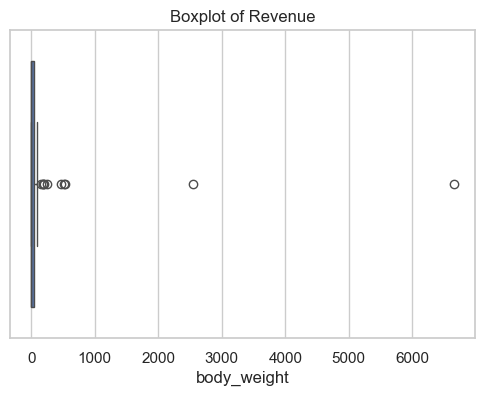

In [85]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['body_weight'])
plt.title("Boxplot of Revenue")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR

The IQR method defines outliers as values outside:



In [86]:
Q1 = df['body_weight'].quantile(0.25)
Q3 = df['body_weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['body_weight'] < lower) | (df['body_weight'] > upper)]
outliers.head(15)

,body_weight,brain_weight,max_life_span,gestation_time,predation_index,sleep_exposure_index,danger_index,total_sleep
0,6654.0,5712.0,38.6,645.0,3,5,3,1970-01-01 00:00:00.000000003
4,2547.0,4603.0,69.0,624.0,3,5,4,1970-01-01 00:00:00.000000003
7,160.0,169.0,30.4,392.0,4,5,4,1970-01-01 00:00:00.000000006
11,465.0,423.0,30.0,281.0,5,5,5,1970-01-01 00:00:00.000000003
13,187.1,419.0,40.0,365.0,5,5,5,1970-01-01 00:00:00.000000003
20,529.0,680.0,28.0,400.0,5,5,5,NaT
23,207.0,406.0,39.3,252.0,1,4,1,1970-01-01 00:00:00.000000012
28,521.0,655.0,46.0,336.0,5,5,5,1970-01-01 00:00:00.000000002
40,250.0,490.0,23.6,440.0,5,5,5,NaT
44,192.0,180.0,27.0,115.0,4,4,4,1970-01-01 00:00:00.000000008


### Remove Outliers


In [87]:
df_no_outliers = df[(df['body_weight'] >= lower) & (df['body_weight'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (62, 8)
After removing outliers:  (52, 8)


The dataset size is slightly reduced.
Removing outliers reduces distortion but may also remove important rare events.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.



In [88]:
lower_cap = df['body_weight'].quantile(0.05)
upper_cap = df['body_weight'].quantile(0.95)

df_capped = df.copy()
df_capped['body_weight'] = df_capped['body_weight'].clip(lower_cap, upper_cap)

## Data Transformation – Normalization


In [89]:
df[['body_weight', 'total_sleep']].head()

,body_weight,total_sleep
0,6654.000,1970-01-01 00:00:00.000000003
1,1.000,1970-01-01 00:00:00.000000008
2,3.385,1970-01-01 00:00:00.000000012
3,0.920,1970-01-01 00:00:00.000000016
4,2547.000,1970-01-01 00:00:00.000000003


In [91]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['body_weight', 'brain_weight']].copy()

df_scaled[['body_weight', 'brain_weight']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,body_weight,brain_weight
0,1.000000,1.000000
1,0.000150,0.001131
2,0.000508,0.007766
3,0.000138,0.000973
4,0.382777,0.805843


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.


### Z-Score Normalization

This method keeps the shape of the distribution but rescales it around zero.

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['body_weight', 'brain_weight']].copy()

df_standardized[['body_weight', 'brain_weight']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,body_weight,brain_weight
0,7.237778,5.883379
1,-0.221768,-0.299686
2,-0.219094,-0.258613
3,-0.221858,-0.300661
4,2.632885,4.681532


## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

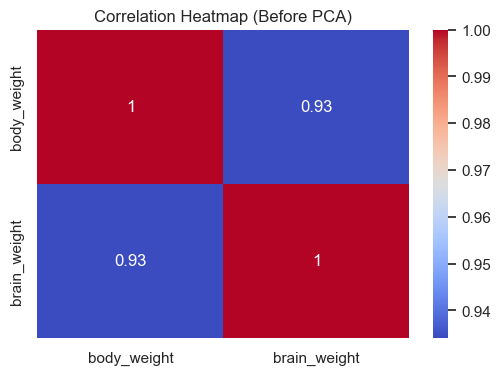

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['body_weight','brain_weight']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `body_weight` and `brain_weight` is approximately *0.93*.

A correlation value close to 1 indicates that there is **linear** relationship between the two features.

This means that `brain_weight` and `body_weight` do move together in a predictable linear pattern.



## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [95]:
from sklearn.decomposition import PCA

X = df_standardized[['body_weight', 'brain_weight']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.96708192 0.03291808]


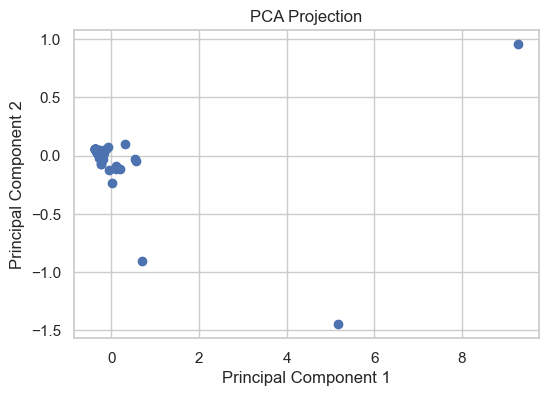

In [96]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one sales transaction.

The axes no longer represent the original features (Amount and Boxes Shipped).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.